In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

Load the dataset

In [22]:
df = pd.read_csv("C:/Users/Admin/Downloads/Unemployment_Rate_M_Total.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
0,Andhra Pradesh,31-01-2016,M,17.91,20626291.0,62.67
1,Andhra Pradesh,29-02-2016,M,9.98,19334918.0,53.50
2,Andhra Pradesh,31-03-2016,M,10.72,19646970.0,54.73
3,Andhra Pradesh,30-04-2016,M,5.51,18929583.0,49.76
4,Andhra Pradesh,31-05-2016,M,6.29,21163390.0,56.02


Inspect the dataset

In [23]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (1822, 6)

Column names:
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)'],
      dtype='object')

Data types:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
0,Andhra Pradesh,31-01-2016,M,17.91,20626291.0,62.67
1,Andhra Pradesh,29-02-2016,M,9.98,19334918.0,53.50
2,Andhra Pradesh,31-03-2016,M,10.72,19646970.0,54.73
3,Andhra Pradesh,30-04-2016,M,5.51,18929583.0,49.76
4,Andhra Pradesh,31-05-2016,M,6.29,21163390.0,56.02


Check missing values

In [24]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
dtype: int64


Clean column names

In [25]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)'],
      dtype='object')


In [26]:
df["Region"] = df["Region"].str.strip()

In [27]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
dtype: object

In [28]:
print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

Minimum date: 2016-01-31 00:00:00
Maximum date: 2021-08-31 00:00:00


Region-wise average unemployment rate

In [29]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Tripura             22.938723
Haryana             18.637500
Jammu & Kashmir     15.139104
Delhi               11.667794
Rajasthan           11.405588
Himachal Pradesh    11.228235
Jharkhand           10.540441
Goa                 10.254627
Bihar               10.147059
Kerala               9.565147
Punjab               8.373971
Uttar Pradesh        8.138971
West Bengal          7.637206
India                7.394412
Puducherry           6.711324
Sikkim               6.418788
Tamil Nadu           5.999265
Assam                5.941176
Andhra Pradesh       5.926912
Chhattisgarh         5.369412
Odisha               5.308088
Maharashtra          5.228676
Madhya Pradesh       4.720735
Telangana            4.525147
Uttarakhand          4.120441
Gujarat              4.110294
Meghalaya            3.905227
Karnataka            3.700735
Name: Estimated Unemployment Rate (%), dtype: float64

Bar chart

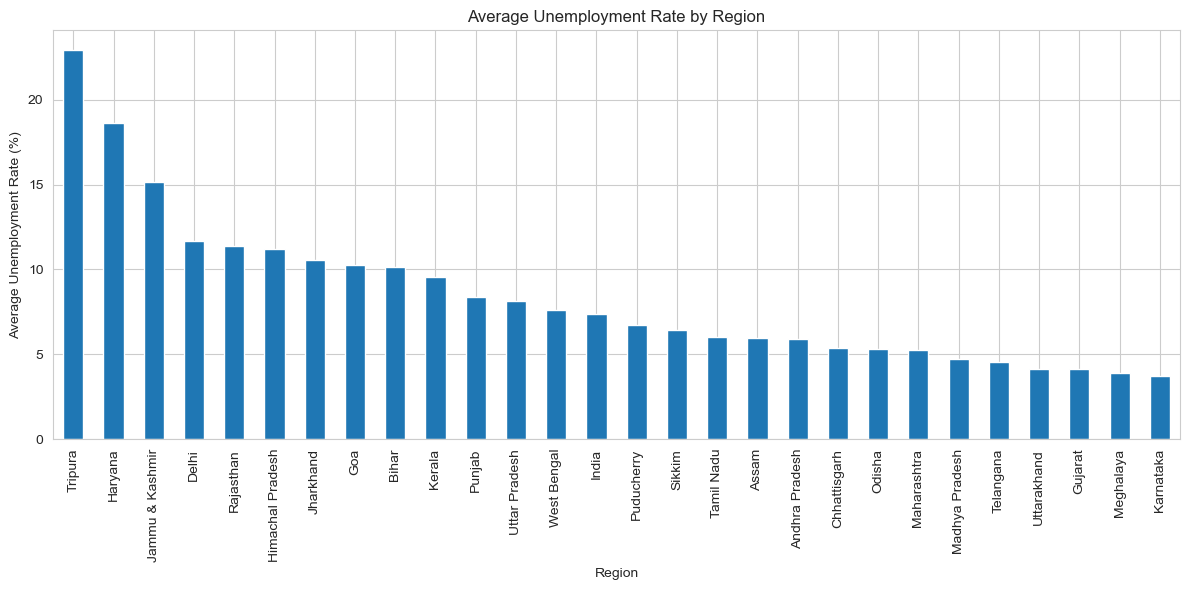

In [30]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Observation:

The average unemployment rate varies considerably across regions. Some regions consistently experience higher unemployment than others, indicating differences in employment opportunities and labour-market conditions.

Month-wise unemployment trend

In [33]:
df["Month"] = df["Date"].dt.month_name()
monthly_avg = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_avg

Date
2016-01     8.664400
2016-02     9.110400
2016-03     8.105600
2016-04     7.567917
2016-05     9.181200
             ...    
2021-04     9.240357
2021-05    13.713214
2021-06    10.602857
2021-07     8.168214
2021-08     8.641429
Freq: M, Name: Estimated Unemployment Rate (%), Length: 68, dtype: float64

Plot

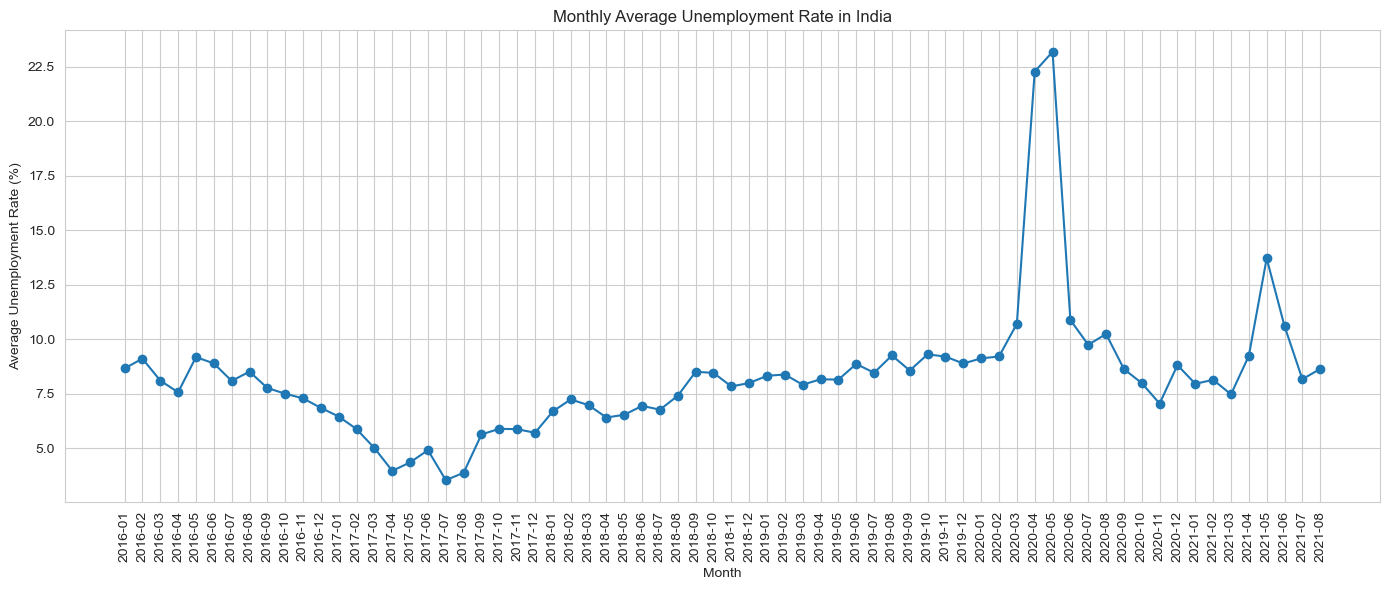

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_avg.index.astype(str),
    monthly_avg.values,
    marker="o"
)

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Observation: The unemployment rate changes significantly over time. A noticeable increase can be observed around the COVID-19 period, reflecting the disruption caused by lockdowns and restrictions on economic activity.

Time-series analysis for 3 major regions

In [35]:
selected_regions = [
    "Andhra Pradesh",
    "Karnataka",
    "Tamil Nadu"
]

In [36]:
df[df["Region"].isin(selected_regions)]["Region"].unique()

array(['Andhra Pradesh', 'Karnataka', 'Tamil Nadu'], dtype=object)

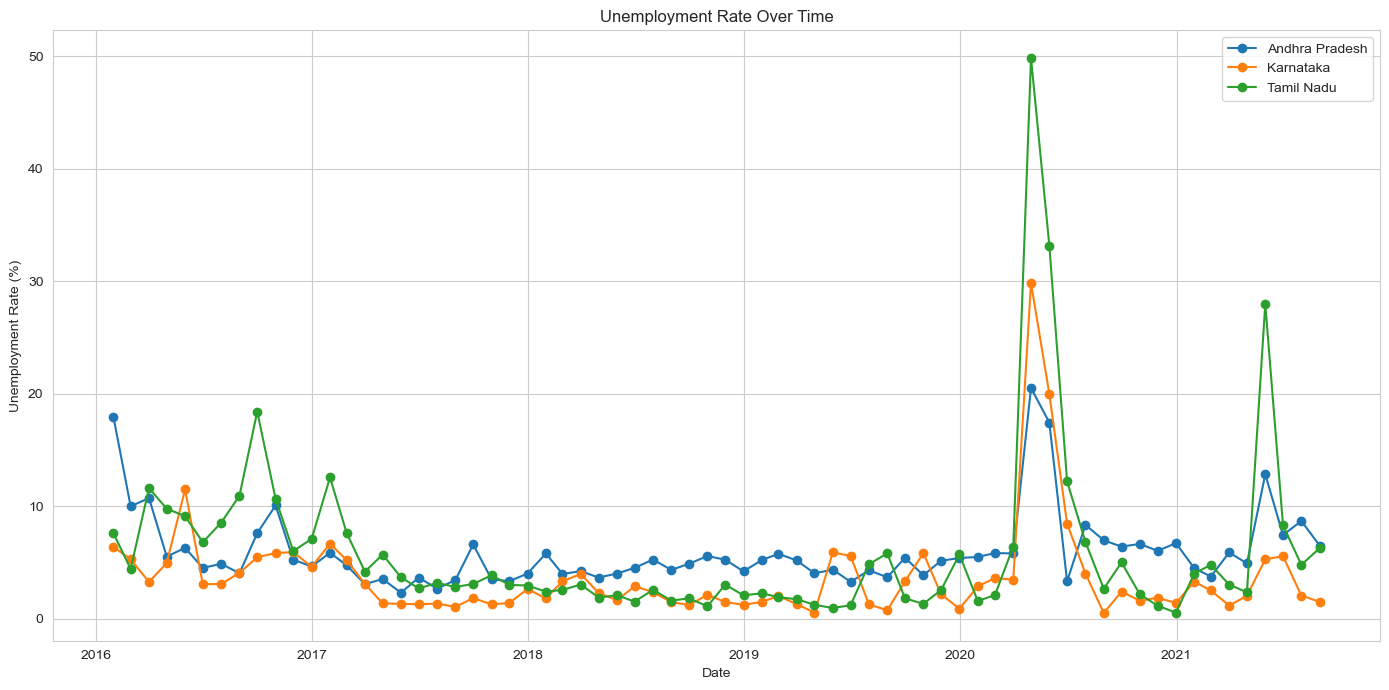

In [37]:
plt.figure(figsize=(14, 7))

for region in selected_regions:
    region_data = df[df["Region"] == region]

    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

Observation:

The unemployment rate fluctuates over time for all three regions. The COVID-19 period shows a substantial increase in unemployment in several regions, although the magnitude and timing of the increase differ between regions.

Top 10 states with highest average unemployment

In [39]:
top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

Region
Tripura             22.938723
Haryana             18.637500
Jammu & Kashmir     15.139104
Delhi               11.667794
Rajasthan           11.405588
Himachal Pradesh    11.228235
Jharkhand           10.540441
Goa                 10.254627
Bihar               10.147059
Kerala               9.565147
Name: Estimated Unemployment Rate (%), dtype: float64

Bar chart

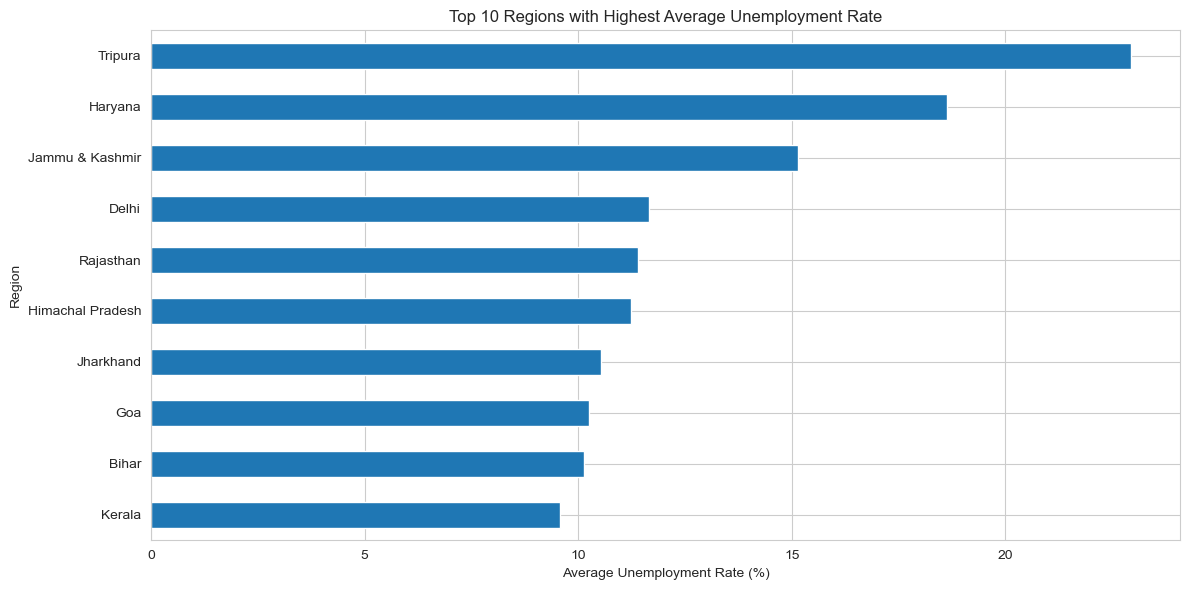

In [40]:
plt.figure(figsize=(12, 6))

top10.sort_values().plot(kind="barh")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

Observation:

The top 10 regions have relatively high average unemployment rates compared with the remaining regions. This highlights considerable regional differences in employment conditions.

Correlation analysis

In [41]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.066305,0.039411
Estimated Employed,-0.066305,1.000000,-0.028809
Estimated Labour Participation Rate (%),0.039411,-0.028809,1.000000


Heatmap

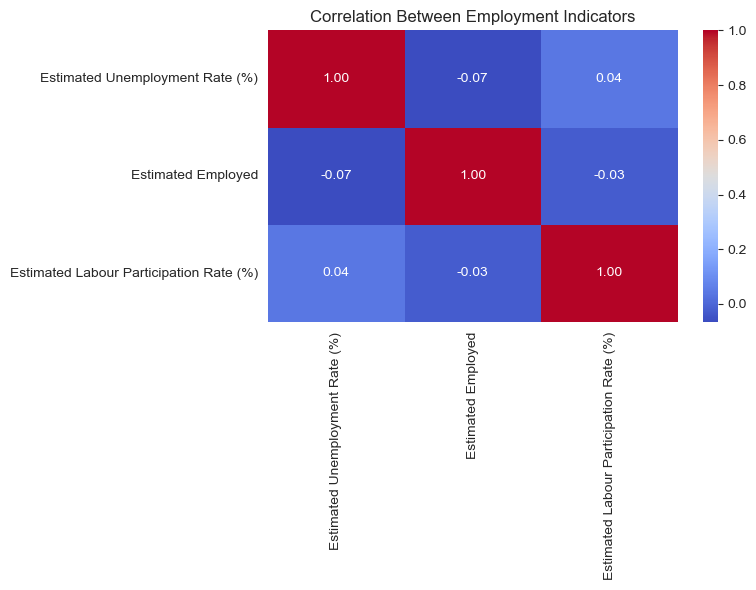

In [42]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

Observation: 

The correlation matrix shows the strength and direction of relationships between unemployment, employment, and labour-force participation indicators. Correlation indicates association between variables and should not automatically be interpreted as causation.

COVID-19 analysis

In [45]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]
print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 1319
Post-COVID records: 503


In [46]:
pre_covid_unemployment = pre_covid["Estimated Unemployment Rate (%)"].mean()

post_covid_unemployment = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID average unemployment rate:",
      round(pre_covid_unemployment, 2), "%")

print("Post-COVID average unemployment rate:",
      round(post_covid_unemployment, 2), "%")

Pre-COVID average unemployment rate: 7.4 %
Post-COVID average unemployment rate: 10.73 %


In [47]:
change = post_covid_unemployment - pre_covid_unemployment

print("Change in unemployment rate:",
      round(change, 2), "percentage points")

Change in unemployment rate: 3.32 percentage points


Compare employment and labour participation

In [48]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Unemployment Rate": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ],
    "Employment": [
        pre_covid["Estimated Employed"].mean(),
        post_covid["Estimated Employed"].mean()
    ],
    "Labour Participation Rate": [
        pre_covid["Estimated Labour Participation Rate (%)"].mean(),
        post_covid["Estimated Labour Participation Rate (%)"].mean()
    ]
})

comparison

,Period,Unemployment Rate,Employment,Labour Participation Rate
0,Pre-COVID,7.401797,3.050061e+07,44.786141
1,Post-COVID,10.726203,2.721294e+07,41.083618


COVID comparison chart

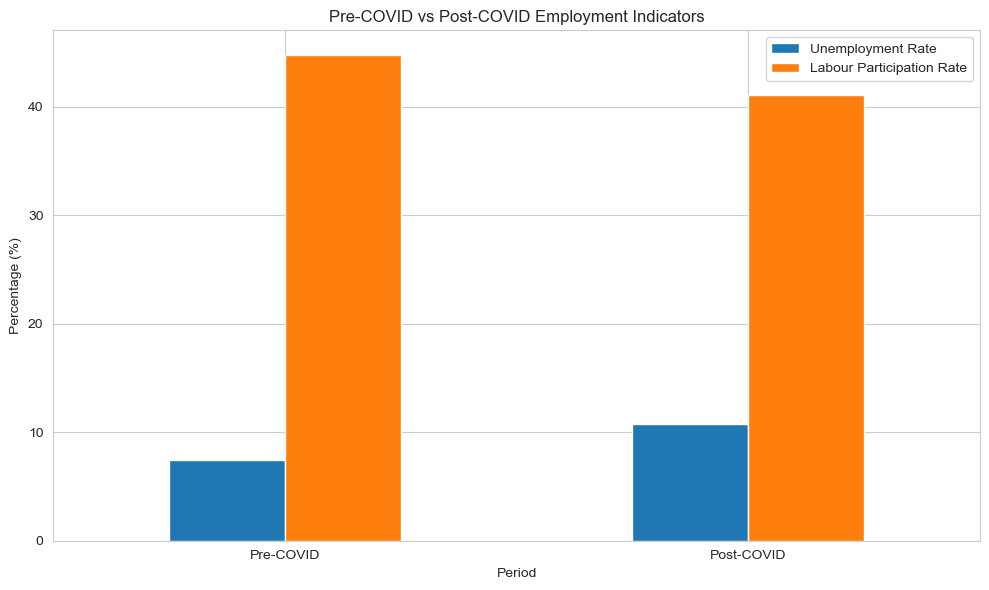

In [49]:
comparison.set_index("Period")[
    ["Unemployment Rate", "Labour Participation Rate"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pre-COVID vs Post-COVID Employment Indicators")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Observation: 

The comparison highlights a clear difference between the pre-COVID and COVID/post-COVID periods. The unemployment rate increased substantially during the pandemic period, while labour-market participation also experienced changes. These changes are consistent with the disruption to economic activity during the pandemic.

Conclusion


This analysis explored unemployment trends across different regions of India using Python, Pandas, Matplotlib, and Seaborn. The analysis examined regional unemployment averages, monthly trends, time-series patterns, the regions with the highest average unemployment rates, and correlations between employment indicators.
The COVID-19 period showed a substantial disruption in India's labour market, with unemployment rates changing noticeably compared with the pre-COVID period. Regional differences were also observed, indicating that the impact was not uniform across all parts of the country.
Overall, exploratory data analysis provides useful insights into temporal and regional patterns in unemployment and demonstrates how Python-based data analysis can be used to investigate real-world economic datasets.